## Libraries Used

In [8]:
import os
import numpy as np
import librosa
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

## Testing Sample Data

In [9]:
import IPython.display as ipd

file_path = r"/Users/shubhamjha/Desktop/Desktop/coding/minor2/first/recording2.0/Utkarsh/No.wav"
ipd.display(ipd.Audio(filename=file_path))

## Data Visualization

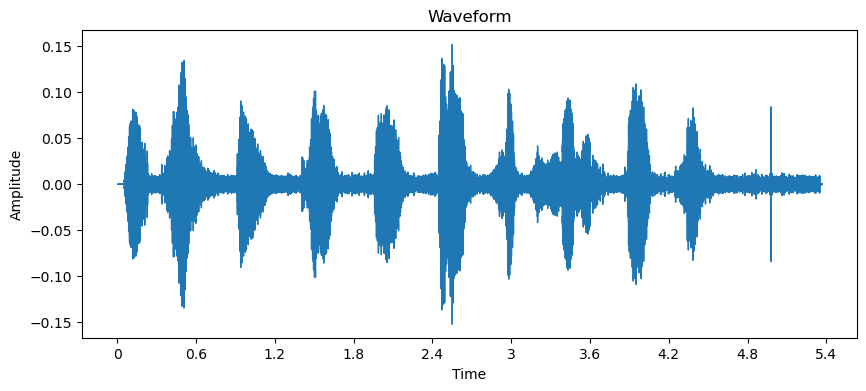

In [10]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

file_path = r"/Users/shubhamjha/Desktop/Desktop/coding/minor2/first/recording2.0/Utkarsh/No.wav"

audio, sr = librosa.load(file_path, sr=16000)

plt.figure(figsize=(10, 4))
librosa.display.waveshow(audio, sr=sr)  # ✅ FIX HERE
plt.title("Waveform")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

## Extracting MFCC and Splitting Dataset

In [11]:

dataset_path = r"/Users/shubhamjha/Desktop/Desktop/coding/minor2/first/recording2.0"

features = []
labels = []

def extract_features(file_path):
    audio, sr = librosa.load(file_path, sr=16000)
    audio, _ = librosa.effects.trim(audio)

    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)

    feature_vector = np.hstack([
        np.mean(mfcc, axis=1),
        np.std(mfcc, axis=1),
        np.mean(delta, axis=1),
        np.mean(delta2, axis=1)
    ])

    return feature_vector

for person in os.listdir(dataset_path):
    person_path = os.path.join(dataset_path, person)

    if os.path.isdir(person_path):
        for file in os.listdir(person_path):
            if file.endswith(".wav"):
                file_path = os.path.join(person_path, file)

                try:
                    features.append(extract_features(file_path))
                    labels.append(person)
                    print(f"Processed: {person}/{file}")
                except Exception as e:
                    print(f"Error in {file}: {e}")

X = np.array(features)
y = np.array(labels)

print("\nFinal Shape:", X.shape)
print("Labels:", set(y))

Processed: Tanish/sentence 2(1).wav
Processed: Tanish/nema no(1).wav
Processed: Tanish/2026_04_26_12_17_28(1).wav
Processed: Tanish/2026_04_26_12_17_00(1).wav
Processed: Tanish/2026_04_26_12_16_48(1).wav
Processed: Tanish/2026_04_26_12_16_37(1).wav
Processed: Tanish/no2(1).wav
Processed: Tanish/sentence (1).wav
Processed: Swayam/Sentence 2 (1).wav
Processed: Swayam/No (2).wav
Processed: Swayam/Passage2 (1).wav
Processed: Swayam/Freeform .wav
Processed: Swayam/Introduction .wav
Processed: Swayam/Passage (2).wav
Processed: Swayam/Sentence  (2).wav
Processed: Swayam/No2 (2).wav
Processed: Sarvagya/No2 2.wav
Processed: Sarvagya/Sentence 2.wav
Processed: Sarvagya/Freeform 2.wav
Processed: Sarvagya/No 2.wav
Processed: Sarvagya/Passage 2.wav
Processed: Sarvagya/Intro2 2.wav
Processed: Sarvagya/Sentence 2 2.wav
Processed: Sarvagya/Intro .wav
Processed: Madhur/mad sen(2).wav
Processed: Madhur/madno2(2).wav
Processed: Madhur/mad intro(2).wav
Processed: Madhur/mad sen2(2).wav
Processed: Madhur/ma

In [12]:
print("Total samples:", len(X))
print("Unique persons:", set(y))

Total samples: 109
Unique persons: {'Vivek', 'Utkarsh', 'Sarvagya', 'Danish', 'ShubhamB', 'Abhishek', 'Madhur', 'Aditya', 'Tanish', 'ShubhamJ', 'Saurabh', 'Vaibhav', 'Swayam', 'Adamya'}


## Model Training

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [14]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

## Model Accuracy

In [15]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7272727272727273


## Live Testing

In [16]:
pip install sounddevice scipy

Note: you may need to restart the kernel to use updated packages.


In [17]:
import sounddevice as sd
from scipy.io.wavfile import write

fs = 22050   # sample rate
seconds = 3  # recording time

print("🎤 Speak now...")
recording = sd.rec(int(seconds * fs), samplerate=fs, channels=1)
sd.wait()

write("test.wav", fs, recording)

print("Recording saved as test.wav")

🎤 Speak now...
Recording saved as test.wav


In [19]:
def predict_voice(file_path):
    import librosa
    import numpy as np

    audio, sr = librosa.load(file_path, sr=16000)
    audio, _ = librosa.effects.trim(audio)

    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)

    feature_vector = np.hstack([
        np.mean(mfcc, axis=1),
        np.std(mfcc, axis=1),
        np.mean(delta, axis=1),
        np.mean(delta2, axis=1)
    ])

    feature_vector = feature_vector.reshape(1, -1)

    print("Feature shape:", feature_vector.shape)  # should be (1, 52)

    prediction = model.predict(feature_vector)
    return prediction[0]


result = predict_voice("/Users/shubhamjha/Desktop/Desktop/coding/minor2/first/test.wav")
print("Detected Voice:", result)

Feature shape: (1, 52)
Detected Voice: ShubhamB


### SVM

In [21]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

scaler = StandardScaler()

# Keep original untouched
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_model = SVC(kernel='rbf', C=10, gamma='scale')

svm_model.fit(X_train_scaled, y_train)

y_pred = svm_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


In [22]:
import sounddevice as sd
from scipy.io.wavfile import write

fs = 16000   # ✅ match training
seconds = 3  # recording time

print("🎤 Speak now...")
recording = sd.rec(int(seconds * fs), samplerate=fs, channels=1)
sd.wait()

write("test.wav", fs, recording)

print("✅ Recording saved as test.wav")


# 🔹 Prediction function
def predict_voice(file_path):
    audio, sr = librosa.load(file_path, sr=16000)
    audio, _ = librosa.effects.trim(audio)

    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)

    feature_vector = np.hstack([
        np.mean(mfcc, axis=1),
        np.std(mfcc, axis=1),
        np.mean(delta, axis=1),
        np.mean(delta2, axis=1)
    ])

    feature_vector = feature_vector.reshape(1, -1)

    print("Feature shape:", feature_vector.shape)  # (1, 52)

    # ✅ IMPORTANT FIX
    feature_vector = scaler.transform(feature_vector)

    prediction = svm_model.predict(feature_vector)

    # Optional confidence
    if hasattr(svm_model, "predict_proba"):
        prob = svm_model.predict_proba(feature_vector).max()
        print(f"Confidence: {prob:.2f}")

    return prediction[0]


# 🔹 Run prediction
result = predict_voice("test.wav")
print("🎤 Detected Voice:", result)

🎤 Speak now...
✅ Recording saved as test.wav
Feature shape: (1, 52)
🎤 Detected Voice: ShubhamB
